# Step 4 — Visual Evaluation

Loads the trained model, runs inference on a single test batch, and visualizes the first 5 images comparing true vs. predicted values for AQI and PM2.5.

In [2]:
import sys
import os
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

REPO_ROOT = Path(os.getcwd())
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from dataset import make_dataset
from model import TARGET_COLS

In [4]:
# 1. Load Model and Scaler
MODEL_PATH = REPO_ROOT / "artifacts" / "best_model.keras"
SCALER_PATH = REPO_ROOT / "artifacts" / "scaler.pkl"

print("Loading model...")
model = tf.keras.models.load_model(str(MODEL_PATH))

print("Loading scaler...")
with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)

# 2. Load the test dataset
print("Loading test dataset...")
test_ds = make_dataset(REPO_ROOT / "data" / "test.csv", batch_size=16, training=False)

Loading model...


c:\Users\Meraj\Desktop\PROJECTS\airsight\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 58 variables whereas the saved optimizer has 62 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loading scaler...
Loading test dataset...


c:\Users\Meraj\Desktop\PROJECTS\airsight\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [5]:
def deprocess_image(img_tensor):
    """Reverses ResNet50 preprocessing to make the image displayable in Matplotlib."""
    img = img_tensor.numpy()
    # ResNet50 preprocessing subtracts ImageNet mean and converts RGB to BGR.
    # 1. Add back the mean
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    # 2. Convert BGR back to RGB
    img = img[..., ::-1]
    return np.clip(img, 0, 255).astype(np.uint8)

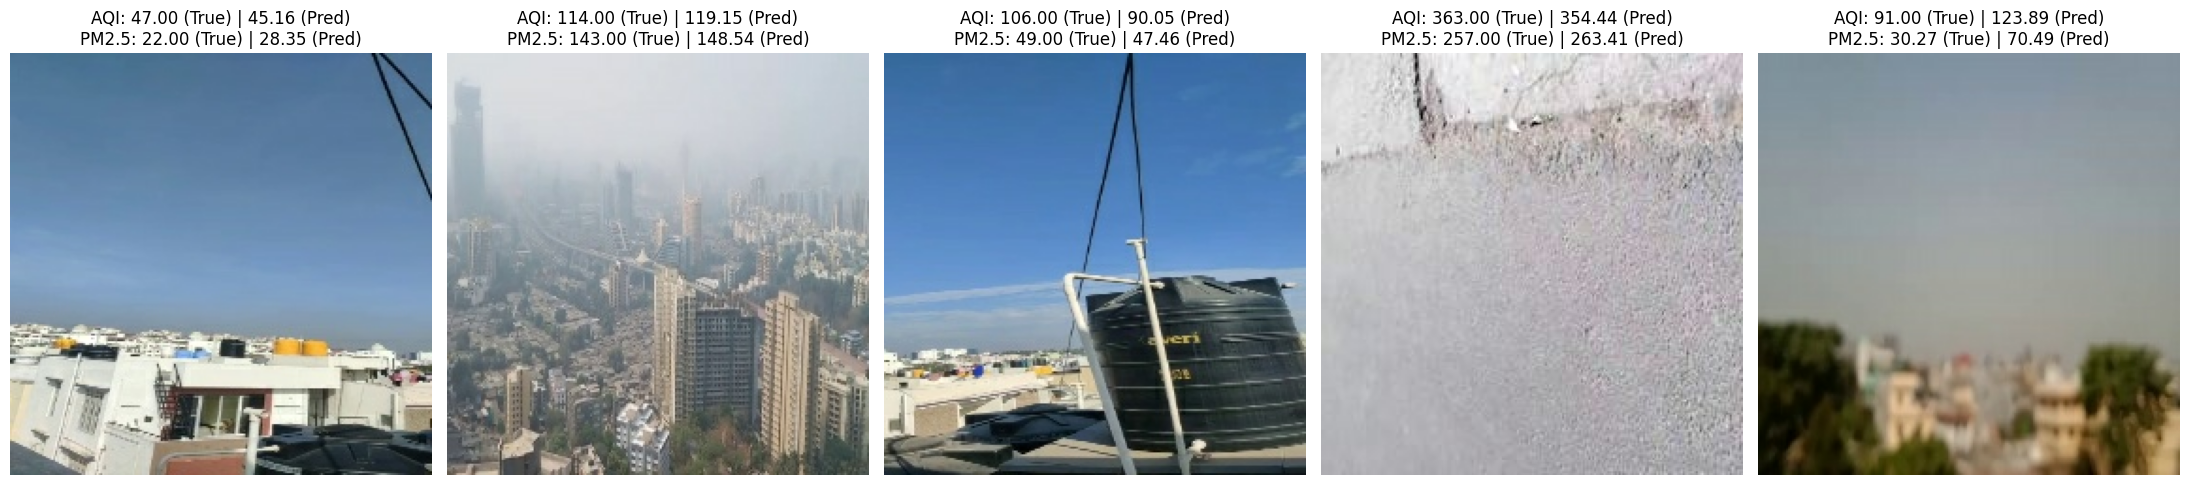

In [6]:
# 3. Grab a single batch of images and their true labels
for images, true_labels in test_ds.take(1):
    break

# 4. Predict on that batch
preds = model.predict(images, verbose=0)

# 5. Reconstruct arrays for scaler.inverse_transform to get real-world units
batch_size = images.shape[0]
true_array = np.zeros((batch_size, len(TARGET_COLS)))
pred_array = np.zeros((batch_size, len(TARGET_COLS)))

for i, col in enumerate(TARGET_COLS):
    true_array[:, i] = true_labels[col].numpy().flatten()
    if isinstance(preds, dict):
        pred_array[:, i] = preds[col].flatten()
    else:
        pred_array[:, i] = preds[i].flatten()

# Inverse transform from standardized values back to true units
true_real = scaler.inverse_transform(true_array)
pred_real = scaler.inverse_transform(pred_array)

# Get indices for AQI and PM2.5
aqi_idx = TARGET_COLS.index("AQI")
pm25_idx = TARGET_COLS.index("PM2.5")

# 6. Create a Matplotlib figure with 5 subplots
fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# 7. Display the first 5 images and their titles
for i in range(5):
    ax = axes[i]
    
    # Deprocess and show image
    img_display = deprocess_image(images[i])
    ax.imshow(img_display)
    ax.axis("off")
    
    # Get actual vs predicted values
    t_aqi = true_real[i, aqi_idx]
    p_aqi = pred_real[i, aqi_idx]
    t_pm = true_real[i, pm25_idx]
    p_pm = pred_real[i, pm25_idx]
    
    # Set title formatting
    title_str = (
        f"AQI: {t_aqi:.2f} (True) | {p_aqi:.2f} (Pred)\n"
        f"PM2.5: {t_pm:.2f} (True) | {p_pm:.2f} (Pred)"
    )
    ax.set_title(title_str, fontsize=12)

plt.tight_layout()
plt.show()